3rd Year Project — Submission-Ready Simulation Script
=====================================================

This script is a cleaned and consolidated version of the working notebook code
used in the project on data pricing models. It is written as a plain `.py`
file with `# %%` cell markers so that it can be converted cleanly into a
Jupyter notebook via `jupytext`.

The script contains two computational components aligned with the dissertation:

1. A binary-tree Monte Carlo simulation studying the effect of information
   propagation / fill assumptions on equilibrium strategies and expected payoffs.
2. A set of analytical visualisations for the sign structure of the summand in
   the quantity \\widetilde{\Delta}_i, used in the asymptotic discussion.

Design goals of this cleaned version:
- remove duplicated code blocks;
- separate core logic from experiments and plotting;
- make parameter choices explicit;
- ensure reproducibility through optional random seeds;
- keep the script supervisor-facing, readable, and easy to convert to notebook form.

In [2]:
from __future__ import annotations

import math
import random
from dataclasses import dataclass, field
from math import comb
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np

## 1. Global plotting style and utility configuration

In [3]:
plt.rcParams.update(
    {
        "figure.figsize": (9, 5),
        "axes.grid": True,
        "grid.alpha": 0.3,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "font.size": 11,
    }
)

DEFAULT_STRATEGY_GRID: Tuple[float, ...] = (0.0, 0.25, 0.5, 0.75, 1.0)

## 2. Core game objects and payoff primitives

In [4]:
@dataclass
class Node:
    """Node in the binary-tree representation of players.

    Parameters
    ----------
    index:
        Array index of the node in the full binary tree.
    data:
        Private data string used to compute the posterior mean estimate `rho_hat`.
    strategy:
        Probability of playing action 1.
    payoff:
        True expected payoff under the global mixed-strategy profile.
    local_payoff:
        Best payoff found during the local subtree optimisation step.
    best_F1_F0:
        Stores `[F1, F0]` for the strategy ultimately selected during optimisation.
    """

    index: int
    data: Sequence[int]
    strategy: float = 0.0
    payoff: float = 0.0
    local_payoff: float = 0.0
    best_F1_F0: List[float] = field(default_factory=list)

    def __post_init__(self) -> None:
        if len(self.data) == 0:
            raise ValueError("Node data must be non-empty.")
        self.rho_hat = round(sum(self.data) / len(self.data), 4)

In [5]:
def player_i_payoff(a_i: int, action_string_without_player_i: Sequence[int], w: int) -> float:
    """Realised payoff of player i.

    The payoff matches the zero-sum winner-split rule used throughout the project.
    If everyone chooses the same action, the payoff is normalised to zero.
    """
    action_string = list(action_string_without_player_i) + [a_i]
    number_correct = sum(1 for x in action_string if x == w)
    win = int(a_i == w)

    if sum(action_string) == 0 or sum(action_string) == len(action_string):
        return 0.0
    return len(action_string) * win / number_correct - 1.0

## 3. Data generation and tree construction

In [6]:
def complicated_bias(i: int) -> float:
    """Non-trivial deterministic bias profile used to generate heterogeneous data."""
    return (
        0.5
        + 0.25 * math.sin(i / 3)
        + 0.15 * math.cos(i * 1.7)
        + 0.1 * math.sin(i**1.2 / 5)
        + 0.05 * math.cos((i + 3) ** 1.1)
    ) % 1.0

In [7]:
def generate_biased_bits(n: int = 100, seed: Optional[int] = None) -> List[int]:
    """Generate a binary string with observation-specific bias."""
    rng = random.Random(seed)
    return [1 if rng.random() < complicated_bias(i) else 0 for i in range(n)]

In [8]:
def get_node_level(index: int) -> int:
    """Return the level of a node in an array-stored full binary tree."""
    return int(math.floor(math.log2(index + 1)))

In [9]:
def generate_binary_tree(
    depth: int,
    data: Optional[Sequence[int]] = None,
    truncate_by_level: bool = True,
) -> List[Node]:
    """Generate a full binary tree of players.

    If `truncate_by_level=True`, deeper nodes receive shorter strings, reflecting
    the information-loss convention used in the original exploratory code.
    """
    if data is None:
        data = generate_biased_bits(1000)

    n_nodes = 2 ** (depth + 1) - 1
    tree: List[Node] = []

    for i in range(n_nodes):
        if truncate_by_level:
            level = get_node_level(i)
            trimmed = list(data[: max(1, len(data) - 10 * (level + 1))])
        else:
            trimmed = list(data)
        tree.append(Node(index=i, data=trimmed))

    return tree

In [10]:
def get_subtree(tree: Sequence[Node], root_index: int) -> List[Node]:
    """Return the subtree rooted at `root_index` in array representation."""
    n = len(tree)
    out: List[Optional[Node]] = []
    queue = [root_index]

    while queue:
        j = queue.pop(0)
        if j < n:
            out.append(tree[j])
            queue.extend([2 * j + 1, 2 * j + 2])
        else:
            out.append(None)

    while out and out[-1] is None:
        out.pop()

    return [node for node in out if node is not None]

## 4. Efficient expected-payoff computation

The simulation treats other players' actions as independent Bernoulli random
variables. Their sum therefore follows a Poisson-binomial law, which is computed
by dynamic programming.

In [11]:
def distribution_sum_bernoulli(prob_list: Sequence[float]) -> np.ndarray:
    """Distribution of the sum of independent Bernoulli variables.

    Returns an array `P` such that `P[k] = P(S = k)`.
    """
    P = np.array([1.0])
    for p in prob_list:
        newP = np.zeros(len(P) + 1)
        for k, pk in enumerate(P):
            newP[k] += pk * (1 - p)
            newP[k + 1] += pk * p
        P = newP
    return P

In [12]:
def payoff_given_others_count(others_k: int, a_i: int, w: int, m_total: int) -> float:
    """Payoff conditional on exactly `others_k` opponents choosing action 1."""
    total_ones = others_k + int(a_i == 1)

    if w == 1:
        winners = total_ones
    else:
        winners = m_total - total_ones

    win = int(a_i == w)

    if total_ones == 0 or total_ones == m_total:
        return 0.0
    return m_total * win / winners - 1.0

In [13]:
def expected_payoff_given_action(a_i: int, node: Node, prob_without_i: Sequence[float]) -> float:
    """Expected payoff of node `i` when it commits to action `a_i`.

    This computes `F_0` or `F_1` depending on the value of `a_i`.
    """
    rho_hat = node.rho_hat
    m_others = len(prob_without_i)
    m_total = m_others + 1
    P_others = distribution_sum_bernoulli(prob_without_i)

    exp_w1 = 0.0
    exp_w0 = 0.0
    for k, pk in enumerate(P_others):
        exp_w1 += pk * payoff_given_others_count(k, a_i, w=1, m_total=m_total)
        exp_w0 += pk * payoff_given_others_count(k, a_i, w=0, m_total=m_total)

    return rho_hat * exp_w1 + (1 - rho_hat) * exp_w0

## 5. Subtree optimisation and global payoff evaluation

In [14]:
def build_subtree(
    subtree: Sequence[Node],
    fill: bool = False,
    total_players: Optional[int] = None,
    strategy_grid: Sequence[float] = DEFAULT_STRATEGY_GRID,
) -> List[Node]:
    """Solve the local optimisation problem by backward induction over a subtree.

    Parameters
    ----------
    subtree:
        List of nodes in array form.
    fill:
        If True, players outside the subtree are assumed to adopt the candidate
        probability `q` currently being tested.
    total_players:
        Total number of players in the full tree.
    strategy_grid:
        Finite grid of admissible mixed strategies.
    """
    solved = [Node(n.index, list(n.data)) for n in subtree]

    for i, original in enumerate(subtree):
        solved[i].strategy = original.strategy

    for node_index in reversed(range(len(solved))):
        node = solved[node_index]
        node_subtree = get_subtree(solved, node_index)
        base_prob_without_i = [n.strategy for n in node_subtree][1:]

        best_q: Optional[float] = None
        best_utility: Optional[float] = None
        best_pair: Optional[List[float]] = None

        for q in strategy_grid:
            if fill:
                if total_players is None:
                    raise ValueError("total_players must be supplied when fill=True.")
                n_outside = total_players - len(node_subtree)
                prob_list = [q] * n_outside + base_prob_without_i
            else:
                prob_list = list(base_prob_without_i)

            F0 = expected_payoff_given_action(0, node, prob_list)
            F1 = expected_payoff_given_action(1, node, prob_list)
            Uq = (1 - q) * F0 + q * F1

            if best_utility is None or Uq > best_utility:
                best_utility = Uq
                best_q = q
                best_pair = [F1, F0]

        node.strategy = float(best_q)
        node.local_payoff = float(best_utility)
        node.best_F1_F0 = best_pair if best_pair is not None else []

    return solved

In [15]:
def compute_actual_payoffs(tree: Sequence[Node]) -> List[Node]:
    """Compute true expected payoffs under the global mixed-strategy profile."""
    evaluated = [Node(n.index, list(n.data)) for n in tree]
    for i, original in enumerate(tree):
        evaluated[i].strategy = original.strategy
        evaluated[i].local_payoff = original.local_payoff
        evaluated[i].best_F1_F0 = list(original.best_F1_F0)

    global_probabilities = [node.strategy for node in evaluated]

    for i, node in enumerate(evaluated):
        p_i = node.strategy
        prob_without_i = global_probabilities[:i] + global_probabilities[i + 1 :]
        F0 = expected_payoff_given_action(0, node, prob_without_i)
        F1 = expected_payoff_given_action(1, node, prob_without_i)
        node.payoff = (1 - p_i) * F0 + p_i * F1

    return evaluated

In [16]:
def single_simulation(
    depth: int,
    data_length: int,
    seed: Optional[int] = None,
    truncate_by_level: bool = True,
    strategy_grid: Sequence[float] = DEFAULT_STRATEGY_GRID,
) -> Dict[str, object]:
    """Run one Monte Carlo instance."""
    data = generate_biased_bits(n=data_length, seed=seed)
    tree = generate_binary_tree(depth=depth, data=data, truncate_by_level=truncate_by_level)

    tree_wo_fill = compute_actual_payoffs(
        build_subtree(
            tree,
            fill=False,
            total_players=len(tree),
            strategy_grid=strategy_grid,
        )
    )
    tree_w_fill = compute_actual_payoffs(
        build_subtree(
            tree,
            fill=True,
            total_players=len(tree),
            strategy_grid=strategy_grid,
        )
    )

    return {
        "data": data,
        "tree": tree,
        "tree_wo_fill": tree_wo_fill,
        "tree_w_fill": tree_w_fill,
        "depth": depth,
        "data_length": data_length,
        "seed": seed,
    }

In [17]:
def run_monte_carlo(
    num_simulations: int,
    depth: int,
    data_length: int = 100,
    base_seed: Optional[int] = None,
    truncate_by_level: bool = True,
    strategy_grid: Sequence[float] = DEFAULT_STRATEGY_GRID,
    verbose: bool = True,
) -> List[Dict[str, object]]:
    """Run repeated Monte Carlo simulations."""
    results: List[Dict[str, object]] = []

    for sim in range(num_simulations):
        seed = None if base_seed is None else base_seed + sim
        if verbose:
            print(f"Running simulation {sim + 1}/{num_simulations} (seed={seed})")
        results.append(
            single_simulation(
                depth=depth,
                data_length=data_length,
                seed=seed,
                truncate_by_level=truncate_by_level,
                strategy_grid=strategy_grid,
            )
        )

    return results

## 6. Aggregation helpers for Monte Carlo output

In [18]:
def payoff_differences_by_node(results: Sequence[Dict[str, object]]) -> np.ndarray:
    """Average payoff difference `(with fill) - (without fill)` by node."""
    if not results:
        raise ValueError("results is empty")

    num_nodes = len(results[0]["tree_wo_fill"])
    avg_diffs = np.zeros(num_nodes)

    for node_idx in range(num_nodes):
        diffs = []
        for run in results:
            wo_node = run["tree_wo_fill"][node_idx]
            w_node = run["tree_w_fill"][node_idx]
            diffs.append(w_node.payoff - wo_node.payoff)
        avg_diffs[node_idx] = float(np.mean(diffs))

    return avg_diffs

In [19]:
def payoff_difference_summary_by_node(
    results: Sequence[Dict[str, object]]
) -> Tuple[np.ndarray, np.ndarray]:
    """Mean and standard deviation of payoff differences by node."""
    if not results:
        raise ValueError("results is empty")

    num_nodes = len(results[0]["tree_wo_fill"])
    means = np.zeros(num_nodes)
    stds = np.zeros(num_nodes)

    for node_idx in range(num_nodes):
        diffs = []
        for run in results:
            wo_node = run["tree_wo_fill"][node_idx]
            w_node = run["tree_w_fill"][node_idx]
            diffs.append(w_node.payoff - wo_node.payoff)
        means[node_idx] = float(np.mean(diffs))
        stds[node_idx] = float(np.std(diffs))

    return means, stds

In [20]:
def payoff_difference_summary_by_level(results: Sequence[Dict[str, object]]) -> Dict[int, Dict[str, object]]:
    """Summary statistics for payoff differences aggregated by tree level."""
    if not results:
        raise ValueError("results is empty")

    num_nodes = len(results[0]["tree_wo_fill"])
    level_to_diffs: Dict[int, List[float]] = {}

    for node_idx in range(num_nodes):
        level = get_node_level(node_idx)
        level_to_diffs.setdefault(level, [])
        for run in results:
            wo_node = run["tree_wo_fill"][node_idx]
            w_node = run["tree_w_fill"][node_idx]
            level_to_diffs[level].append(w_node.payoff - wo_node.payoff)

    summary: Dict[int, Dict[str, object]] = {}
    for level, values in level_to_diffs.items():
        arr = np.asarray(values, dtype=float)
        n = len(arr)
        std = float(np.std(arr, ddof=1)) if n > 1 else 0.0
        se = std / math.sqrt(n) if n > 1 else 0.0
        summary[level] = {
            "values": arr,
            "mean": float(np.mean(arr)),
            "std": std,
            "se": se,
            "ci95": 1.96 * se,
            "n": n,
        }

    return summary

## 7. Plotting: simulation output

In [21]:
def plot_strategy_distribution(tree_wo_fill: Sequence[Node], tree_w_fill: Sequence[Node]) -> None:
    node_indices = [node.index for node in tree_wo_fill]
    wo_fill_strats = [node.strategy for node in tree_wo_fill]
    w_fill_strats = [node.strategy for node in tree_w_fill]

    plt.figure()
    plt.plot(node_indices, wo_fill_strats, "o-", label="Without fill")
    plt.plot(node_indices, w_fill_strats, "s-", label="With fill")
    plt.xlabel("Node index")
    plt.ylabel("Strategy probability $P(a=1)$")
    plt.title("Node strategy distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [22]:
def plot_payoff_distribution(tree_wo_fill: Sequence[Node], tree_w_fill: Sequence[Node]) -> None:
    node_indices = [node.index for node in tree_wo_fill]
    wo_fill_payoffs = [node.payoff for node in tree_wo_fill]
    w_fill_payoffs = [node.payoff for node in tree_w_fill]

    plt.figure()
    plt.plot(node_indices, wo_fill_payoffs, "o-", label="Without fill")
    plt.plot(node_indices, w_fill_payoffs, "s-", label="With fill")
    plt.xlabel("Node index")
    plt.ylabel("Expected payoff")
    plt.title("Node payoff distribution")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [23]:
def plot_average_payoff_difference(results: Sequence[Dict[str, object]]) -> None:
    means, _ = payoff_difference_summary_by_node(results)
    plt.figure()
    plt.bar(range(len(means)), means)
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("Node index")
    plt.ylabel("Average payoff difference\n(with fill $-$ without fill)")
    plt.title("Average payoff difference per node over Monte Carlo simulations")
    plt.tight_layout()
    plt.show()

In [24]:
def plot_average_payoff_difference_with_spread(results: Sequence[Dict[str, object]]) -> None:
    means, stds = payoff_difference_summary_by_node(results)
    plt.figure()
    plt.bar(range(len(means)), means, yerr=stds, capsize=4)
    plt.axhline(0.0, linewidth=1)
    plt.xlabel("Node index")
    plt.ylabel("Average payoff difference\n(with fill $-$ without fill)")
    plt.title("Average payoff difference per node with spread")
    plt.tight_layout()
    plt.show()

In [25]:
def plot_payoff_difference_by_level(results: Sequence[Dict[str, object]], show_boxplot: bool = True) -> None:
    stats = payoff_difference_summary_by_level(results)
    levels = sorted(stats.keys())
    means = [stats[level]["mean"] for level in levels]
    cis95 = [stats[level]["ci95"] for level in levels]

    if show_boxplot:
        fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    else:
        fig, ax = plt.subplots(figsize=(7, 5))
        axes = [ax]

    axes[0].errorbar(levels, means, yerr=cis95, fmt="o-", capsize=4)
    axes[0].axhline(0.0, linewidth=1)
    axes[0].set_xlabel("Tree level")
    axes[0].set_ylabel("Payoff difference (with fill $-$ without fill)")
    axes[0].set_title("Average payoff difference by tree level")
    axes[0].set_xticks(levels)

    if show_boxplot:
        box_data = [stats[level]["values"] for level in levels]
        axes[1].boxplot(box_data, tick_labels=levels, showfliers=False)
        axes[1].axhline(0.0, linewidth=1)
        axes[1].set_xlabel("Tree level")
        axes[1].set_ylabel("Payoff difference (with fill $-$ without fill)")
        axes[1].set_title("Distribution of payoff differences by tree level")

    plt.tight_layout()
    plt.show()

In [26]:
def get_tree_positions(num_nodes: int) -> Dict[int, Tuple[float, float]]:
    """Plotting coordinates for a full binary tree."""
    positions: Dict[int, Tuple[float, float]] = {}
    for i in range(num_nodes):
        level = get_node_level(i)
        first_idx_at_level = 2**level - 1
        pos_in_level = i - first_idx_at_level
        n_on_level = 2**level
        x = (pos_in_level + 1) / (n_on_level + 1)
        y = -level
        positions[i] = (x, y)
    return positions

In [27]:
def plot_tree_heatmap(results: Sequence[Dict[str, object]], annotate: bool = False) -> None:
    avg_diffs = payoff_differences_by_node(results)
    num_nodes = len(avg_diffs)
    positions = get_tree_positions(num_nodes)

    fig, ax = plt.subplots(figsize=(12, 7))

    vmin = float(np.min(avg_diffs))
    vmax = float(np.max(avg_diffs))
    if np.isclose(vmin, vmax):
        vmin, vmax = vmin - 1e-9, vmax + 1e-9
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    for i in range(num_nodes):
        x0, y0 = positions[i]
        for child in (2 * i + 1, 2 * i + 2):
            if child < num_nodes:
                x1, y1 = positions[child]
                ax.plot([x0, x1], [y0, y1], color="gray", linewidth=1, alpha=0.6)

    xs = [positions[i][0] for i in range(num_nodes)]
    ys = [positions[i][1] for i in range(num_nodes)]
    scatter = ax.scatter(
        xs,
        ys,
        c=avg_diffs,
        cmap="coolwarm",
        norm=norm,
        s=900 / (1 + math.log2(num_nodes)),
        edgecolors="black",
        linewidths=0.8,
        zorder=3,
    )

    if annotate:
        for i in range(num_nodes):
            x, y = positions[i]
            ax.text(x, y, str(i), ha="center", va="center", fontsize=8)

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Average payoff difference (with fill $-$ without fill)")

    ax.set_title("Binary tree heatmap of average payoff differences")
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

## 8. Analytical plots for the summand in \\widetilde{\Delta}_i

These figures are designed to support the theoretical discussion in the later
part of the dissertation, where the sign of the summand is decomposed into a
probability term, a weighting term, and a linear sign term.

In [28]:
def P_i(k: int, q: float, N: int) -> float:
    """Binomial mass function for `K_i ~ Bin(N-1, q)` evaluated at `k`."""
    return comb(N - 1, k) * (q**k) * ((1 - q) ** (N - 1 - k))

In [29]:
def g_weight(k: int, N: int) -> float:
    """Weighting term appearing in the summand."""
    return N / ((k + 1) * (N - k))

In [30]:
def f_i(k: int, rho: float, N: int) -> float:
    """Linear sign term appearing in the summand."""
    return rho * (N + 1) - (k + 1)

In [31]:
def delta_components(N: int, q_i: float, rho_i: float) -> Dict[str, np.ndarray]:
    """Return the components of the summand used in the \\widetilde{\Delta}_i plots."""
    k_vals = np.arange(0, N)
    P_vals = np.array([P_i(k, q_i, N) for k in k_vals], dtype=float)
    g_vals = np.array([g_weight(k, N) for k in k_vals], dtype=float)
    f_vals = np.array([f_i(k, rho_i, N) for k in k_vals], dtype=float)
    prod_vals = P_vals * g_vals * f_vals
    k_star = rho_i * (N + 1) - 1

    return {
        "k": k_vals,
        "P": P_vals,
        "g": g_vals,
        "f": f_vals,
        "product": prod_vals,
        "k_star": np.array([k_star]),
    }

In [32]:
def plot_delta_decomposition(N: int, q_i: float, rho_i: float) -> None:
    """Four-panel decomposition of the summand contributing to \\widetilde{\Delta}_i."""
    comp = delta_components(N=N, q_i=q_i, rho_i=rho_i)
    k_vals = comp["k"]
    P_vals = comp["P"]
    g_vals = comp["g"]
    f_vals = comp["f"]
    prod_vals = comp["product"]
    k_star = float(comp["k_star"][0])

    fig, axes = plt.subplots(1, 4, figsize=(22, 5))

    axes[0].plot(k_vals, P_vals, linewidth=2)
    axes[0].axvline(k_star, linestyle="--", label=rf"$k_i^* = {k_star:.2f}$")
    axes[0].set_title(r"Distribution $P_i(k)$")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel(r"$P_i(k)$")
    axes[0].legend()

    axes[1].plot(k_vals, f_vals, linewidth=2)
    axes[1].axhline(0.0, linestyle="--")
    axes[1].axvline(k_star, linestyle="--", label=rf"$k_i^* = {k_star:.2f}$")
    axes[1].set_title(r"Sign term $f_i(k)$")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel(r"$f_i(k)$")
    axes[1].legend()

    axes[2].plot(k_vals, g_vals, linewidth=2)
    axes[2].set_title(r"Weighting term $g(k)$")
    axes[2].set_xlabel("k")
    axes[2].set_ylabel(r"$g(k)$")

    markerline, stemlines, baseline = axes[3].stem(k_vals, prod_vals, basefmt=" ")
    plt.setp(stemlines, linewidth=1.2)
    axes[3].axhline(0.0, linestyle="--")
    axes[3].axvline(k_star, linestyle="--", label=rf"$k_i^* = {k_star:.2f}$")
    axes[3].set_title(r"Summand $P_i(k)g(k)f_i(k)$")
    axes[3].set_xlabel("k")
    axes[3].set_ylabel(r"$P_i(k)g(k)f_i(k)$")
    axes[3].legend()

    plt.tight_layout()
    plt.show()

## 9. Submission-facing experiment cells

The next cells provide a minimal and tidy set of experiments suitable for
showing the computational pipeline to a supervisor. They are not executed on
import; run them manually after conversion to notebook.

In [ ]:
SUBMISSION_EXPERIMENTS = {
    "depth_3": {"num_simulations": 1000, "depth": 3, "data_length": 100, "base_seed": 1000},
    "depth_5": {"num_simulations": 1000, "depth": 5, "data_length": 100, "base_seed": 3000},
    "depth_7": {"num_simulations": 500, "depth": 7, "data_length": 100, "base_seed": 4000},
}

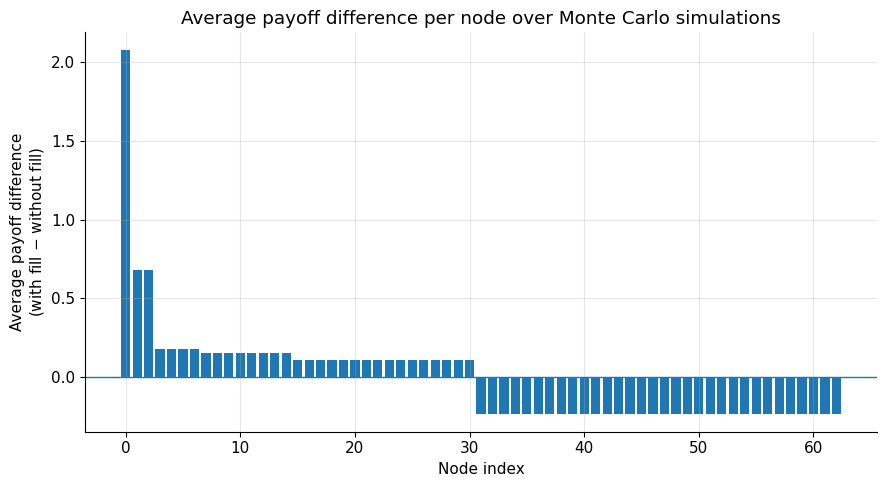

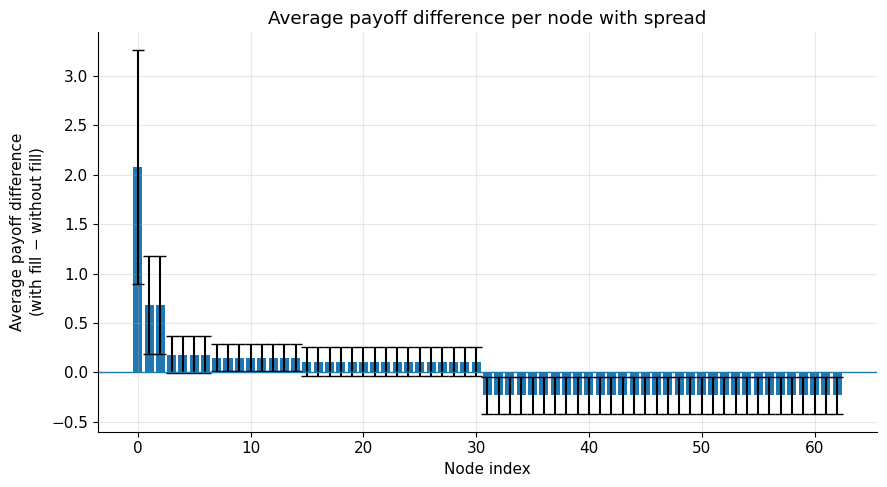

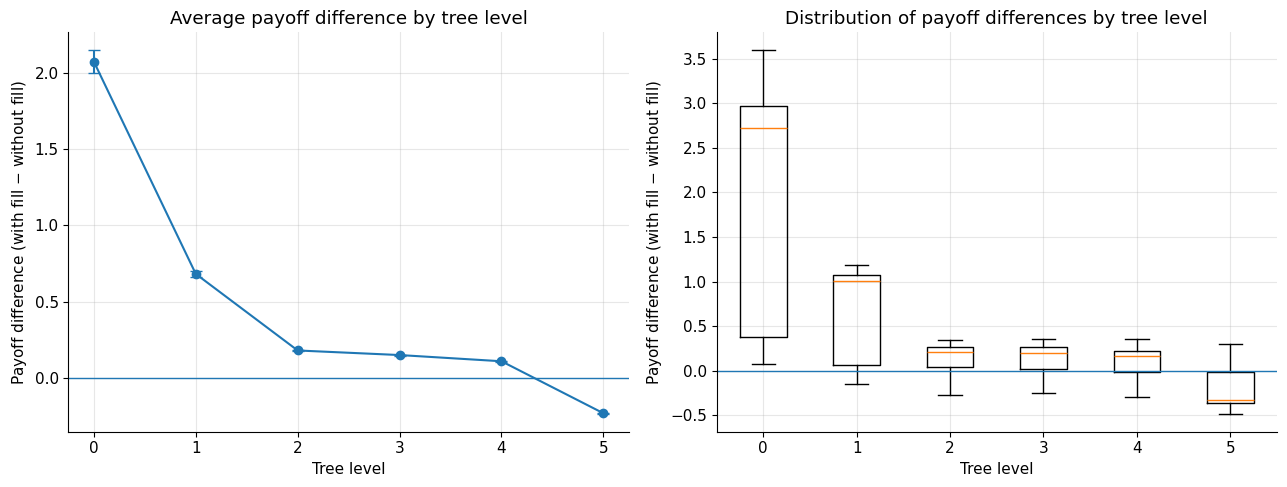

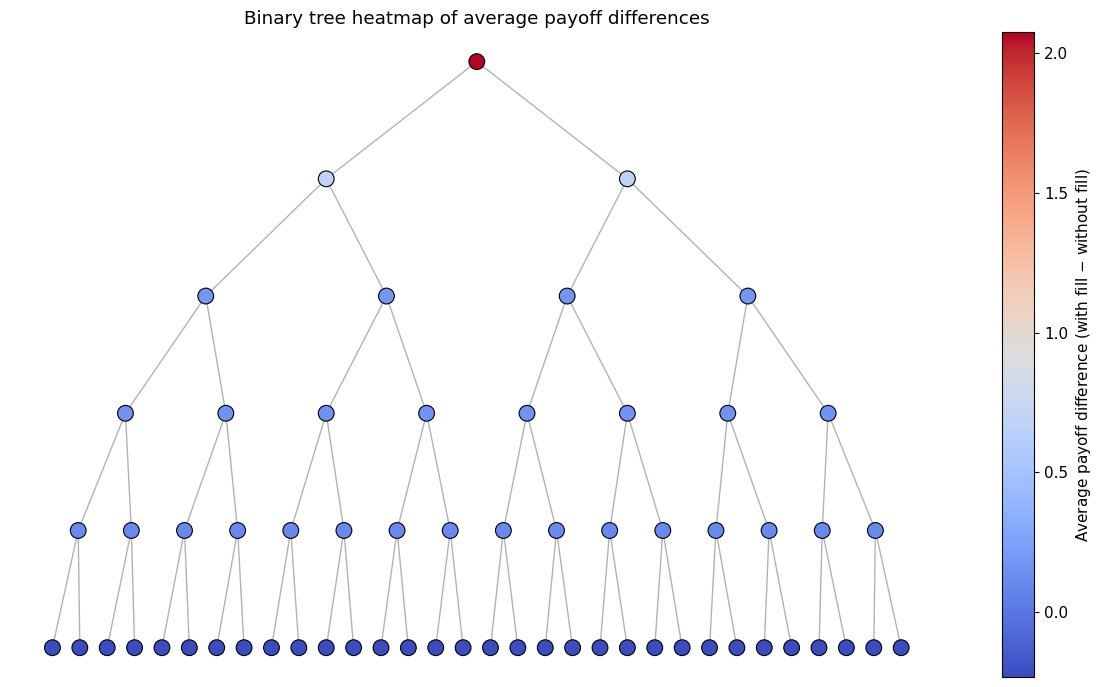

In [35]:
# Example supervisor-facing run for one configuration.
# Uncomment to execute after conversion to notebook.

results_5 = run_monte_carlo(**SUBMISSION_EXPERIMENTS["depth_5"], verbose=False)
plot_average_payoff_difference(results_5)
plot_average_payoff_difference_with_spread(results_5)
plot_payoff_difference_by_level(results_5, show_boxplot=True)
plot_tree_heatmap(results_5, annotate=False)

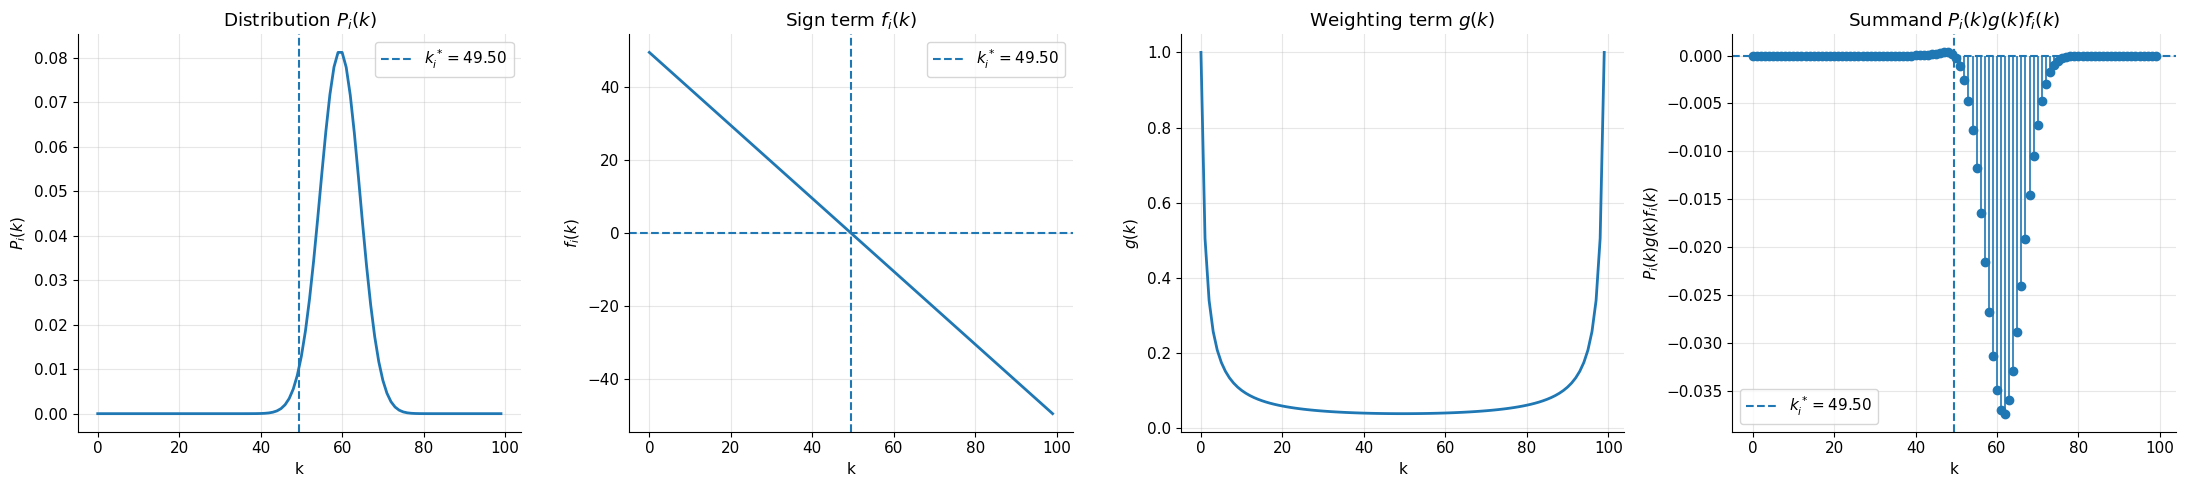

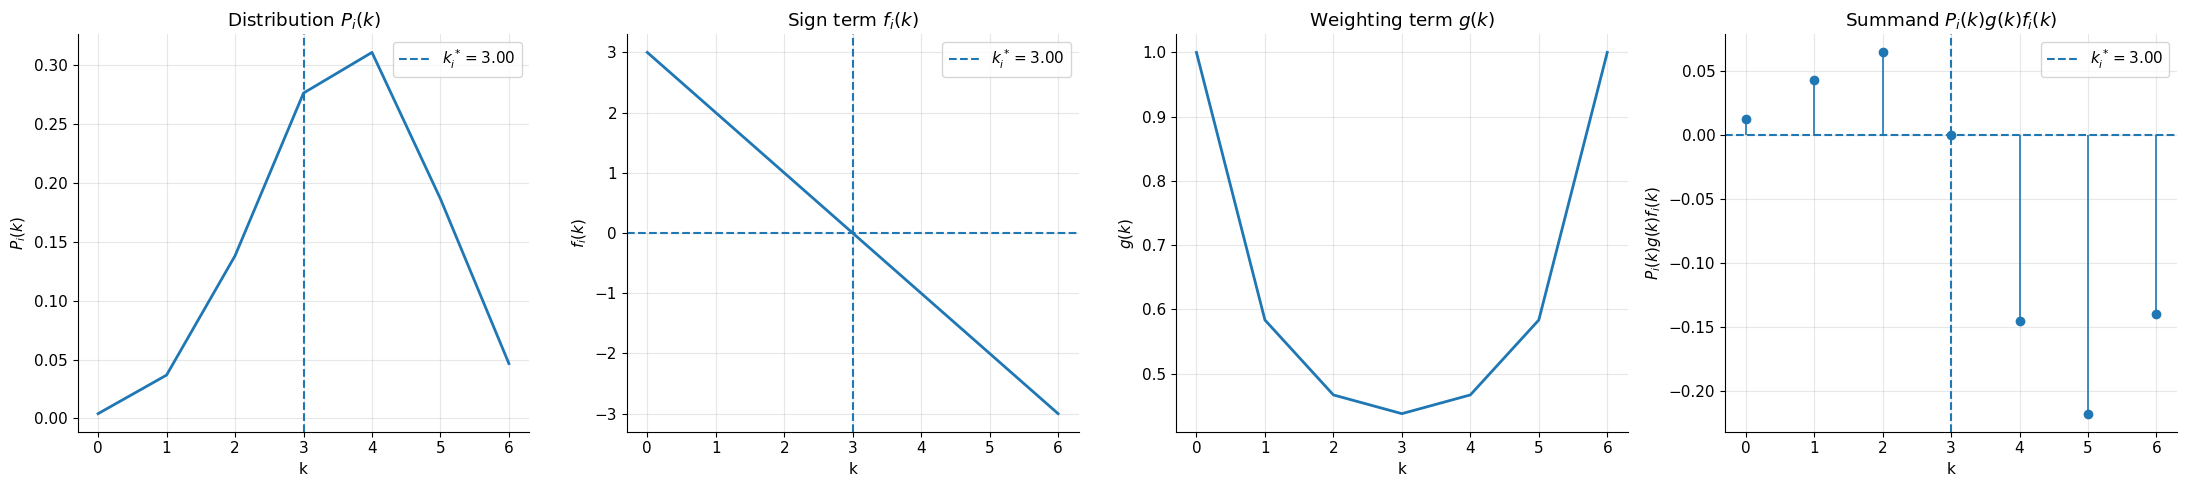

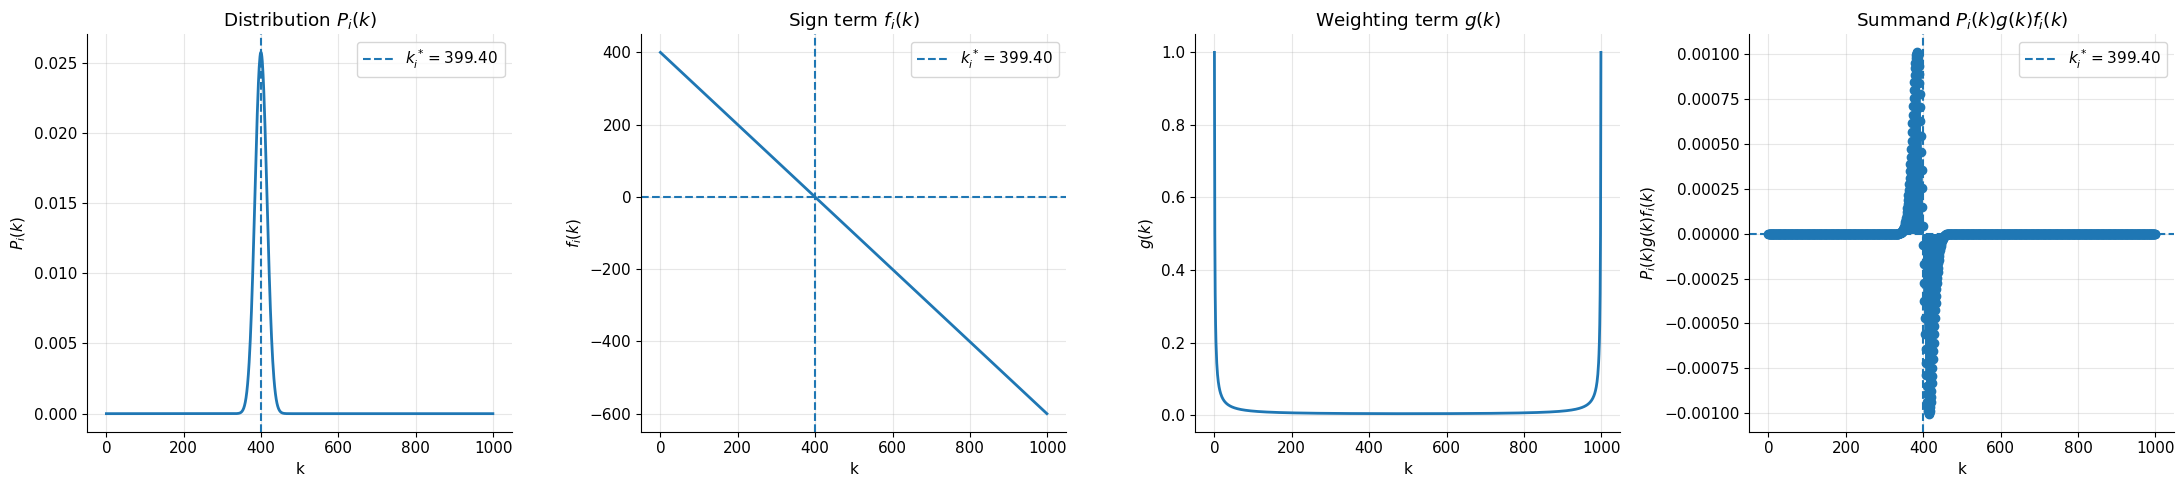

In [36]:
# Example analytical figure from the \widetilde{\Delta}_i discussion.
# Uncomment to execute.

plot_delta_decomposition(N=100, q_i=0.6, rho_i=0.5)
plot_delta_decomposition(N=7, q_i=0.6, rho_i=0.5)
plot_delta_decomposition(N=1000, q_i=0.4, rho_i=0.4)

## 10. Optional helper for saving figures in a submission folder

In [ ]:
def save_current_figure(filename: str, folder: str = "figures", dpi: int = 300) -> Path:
    """Save the current matplotlib figure to `folder/filename`."""
    out_dir = Path(folder)
    out_dir.mkdir(parents=True, exist_ok=True)
    path = out_dir / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    return path

## 11. Notes for supervisor submission

Suggested workflow after converting this file with `jupytext`:

1. Run the imports and core function cells.
2. Execute one representative Monte Carlo block (for example depth 5).
3. Produce the payoff-by-node, payoff-by-level, and tree-heatmap figures.
4. Produce one or two \\widetilde{\Delta}_i decomposition figures used in the theory section.
5. Save final figures into a dedicated `figures/` directory if needed.

This script intentionally excludes exploratory, duplicated, and interactive-only
widgets so that the computational narrative remains compact and submission-ready.